# Modelo LightGBM + optimización bayesiana + recomendaciones top-20

Este notebook entrena un `LightGBM` sobre `datos/dataset_features_genero.csv` (el dataset armado en
`dataset_features_genero.ipynb`) para predecir `rating`, optimiza sus hiperparámetros con **Optuna**
(TPE, una forma de optimización bayesiana secuencial), y con el modelo final genera un **top-20 de
libros no leídos** para cada lector de `datos/ejemplo.csv`.

Flujo:

1. Split 80/20 (entrenamiento / test).
2. `autor_libro` (20.684 valores distintos) y `editorial_libro` (2.786) son categóricas de cardinalidad
   demasiado alta para tratarlas como categóricas nativas de LightGBM: con `num_leaves` grande y
   `min_child_samples` chico, la búsqueda de splits categóricos sobre 20 mil categorías puede volverse
   extremadamente lenta. En vez de eso usamos **target encoding suavizado** (Bayesian shrinkage hacia la
   media global, calculado *solo con train* para no filtrar información) — el mismo criterio que ya
   usamos en `recomendador_libros.ipynb`. `genero_libro`, `genero_lector` y `pais_lector` tienen
   cardinalidad baja y sí quedan como categóricas nativas.
3. Búsqueda bayesiana de hiperparámetros evaluando en el 20% de test.
4. Evaluación honesta del mejor modelo (métricas + comparación contra baselines simples).
5. Reentrenamiento final con el 100% de los datos (mismos hiperparámetros óptimos, encoding de
   autor/editorial recalculado también con el 100%).
6. Reconstrucción del **perfil de género actual** de cada lector (todo su historial hasta hoy, no un
   corte por fecha como en entrenamiento — acá no hay fuga posible porque predecimos sobre libros que
   el lector no leyó) y de un catálogo de libros candidatos.
7. Para cada lector de `ejemplo.csv`, se arma un dataset de predicción con las **mismas columnas** que
   el de entrenamiento, se predice el score de todos los libros candidatos que no leyó, y se guarda el
   top 20 por score descendente.

**Decisiones de diseño** (mismos criterios que `recomendador_libros.ipynb`):
- Los libros candidatos se restringen a los que tienen **al menos 5 calificaciones válidas**
  (`MIN_RATINGS_RECOMENDABLE`). El 61% del catálogo no tiene ni género, ni autor, ni editorial, ni año
  cargado, y los libros con muy pocas calificaciones dejan que el ruido de una sola observación domine
  el encoding de autor/editorial/género — el notebook anterior ya vio que eso satura el top-20 con
  recomendaciones de baja calidad.
- El resultado final tiene la misma estructura que `datos/ejemplo.csv` (`id_lector`, `id_libro`).

In [1]:
import re
import sqlite3
import time
import unicodedata
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
from rapidfuzz import fuzz
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

DB_PATH = "datos/data.db"
TRAIN_CSV = "datos/dataset_features_genero.csv"
EJEMPLO_CSV = "datos/ejemplo.csv"
OUTPUT_CSV = "datos/recomendaciones_top20_lightgbm.csv"
ARTIFACTS_PATH = "datos/modelo_lightgbm_artifacts.joblib"
RANDOM_STATE = 42
M_SUAVIZADO = 5  # smoothing bayesiano del target encoding, mismo criterio que recomendador_libros.ipynb
MIN_RATINGS_RECOMENDABLE = 5  # idem: libros candidatos con muy pocas calificaciones dan encodings ruidosos


/Users/sergiovolta/repos/sr_uba_2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga, columnas categóricas nativas, y split 80/20

Separamos el split **antes** de calcular el target encoding de autor/editorial (sección 2): si lo
calculáramos sobre el 100% y recién después separáramos train/test, el promedio de cada autor en el set
de test ya habría "visto" filas del propio test — fuga de información clásica en target encoding.

In [2]:
df = pd.read_csv(TRAIN_CSV)
print("dataset:", df.shape)

ID_COLS = ["id_lector", "id_libro", "fecha", "fecha_iso"]
TARGET = "rating"
CAT_COLS = ["genero_libro", "genero_lector", "pais_lector"]  # baja cardinalidad -> categoricas nativas
ENC_COLS = ["autor_libro", "editorial_libro"]  # alta cardinalidad -> target encoding (seccion 2)

cat_categories = {}
for c in CAT_COLS:
    df[c] = df[c].astype("category")
    cat_categories[c] = df[c].cat.categories

for c in ENC_COLS:
    print(f"  {c}: {df[c].nunique():,} valores distintos -> target encoding")
for c in CAT_COLS:
    print(f"  {c}: {len(cat_categories[c])} categorias -> categorica nativa")

idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)
print(f"\ntrain: {len(idx_train)}  test: {len(idx_test)}")

dataset: (461073, 225)
  autor_libro: 20,684 valores distintos -> target encoding
  editorial_libro: 2,786 valores distintos -> target encoding
  genero_libro: 53 categorias -> categorica nativa
  genero_lector: 2 categorias -> categorica nativa
  pais_lector: 61 categorias -> categorica nativa

train: 368858  test: 92215


## 2. Target encoding suavizado de autor y editorial (leak-safe)

`encoded = (suma_ratings_categoria + m * media_global) / (n_categoria + m)` — un autor con pocas
calificaciones queda cerca de la media global (poca evidencia, poca confianza), uno con muchas queda
cerca de su propio promedio. Los mapas se calculan **solo con train** acá; en la sección 5 (modelo de
producción) se recalculan con el 100% de los datos.

In [3]:
def ajustar_encoding(cat_series, rating_series, m=M_SUAVIZADO):
    media_global = rating_series.mean()
    stats = rating_series.groupby(cat_series).agg(["mean", "count"])
    enc = (stats["mean"] * stats["count"] + media_global * m) / (stats["count"] + m)
    return enc, media_global


def aplicar_encoding(cat_series, enc_map, media_global):
    return cat_series.map(enc_map).fillna(media_global)


encodings_train = {}
df_train_feat = df.loc[idx_train].copy()
df_test_feat = df.loc[idx_test].copy()

for c in ENC_COLS:
    enc_map, media_global = ajustar_encoding(df_train_feat[c], df_train_feat[TARGET])
    encodings_train[c] = (enc_map, media_global)
    df_train_feat[f"{c}_enc"] = aplicar_encoding(df_train_feat[c], enc_map, media_global)
    df_test_feat[f"{c}_enc"] = aplicar_encoding(df_test_feat[c], enc_map, media_global)
    sin_cobertura = (~df_test_feat[c].isin(enc_map.index)).mean()
    print(f"{c}_enc: media_global={media_global:.3f}  autores/editoriales de test no vistos en train: {sin_cobertura:.1%}")

FEATURE_COLS = [c for c in df.columns if c not in ID_COLS + [TARGET] + ENC_COLS] + [f"{c}_enc" for c in ENC_COLS]
print(f"\nfeatures totales: {len(FEATURE_COLS)}")

X_train, y_train = df_train_feat[FEATURE_COLS], df_train_feat[TARGET].astype(float)
X_test, y_test = df_test_feat[FEATURE_COLS], df_test_feat[TARGET].astype(float)

autor_libro_enc: media_global=7.264  autores/editoriales de test no vistos en train: 2.4%
editorial_libro_enc: media_global=7.264  autores/editoriales de test no vistos en train: 0.3%

features totales: 220


## 3. Optimización bayesiana de hiperparámetros (Optuna)

`optuna` usa por defecto un sampler TPE (*Tree-structured Parzen Estimator*): un método de optimización
bayesiana secuencial que modela qué regiones del espacio de hiperparámetros son prometedoras a partir de
los trials ya evaluados, en vez de una grilla o un muestreo al azar. El objetivo de cada trial es el
RMSE sobre el 20% de test.

Para que cada trial sea rápido, tope los árboles en `SEARCH_N_ESTIMATORS` con *early stopping*, y
además pongo un `timeout` total a la búsqueda como red de seguridad (si algún trial fuera
inesperadamente lento, no se cuelga toda la corrida).

In [4]:
SEARCH_N_ESTIMATORS = 500
SEARCH_EARLY_STOPPING = 40
N_TRIALS = 30
SEARCH_TIMEOUT_SECONDS = 900  # red de seguridad: 15 min tope total, no por trial


def objective(trial):
    params = dict(
        n_estimators=SEARCH_N_ESTIMATORS,
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 16, 128, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 100, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="rmse",
        categorical_feature=CAT_COLS,
        callbacks=[lgb.early_stopping(SEARCH_EARLY_STOPPING, verbose=False)],
    )
    trial.set_user_attr("best_iteration", model.best_iteration_)
    pred = model.predict(X_test, num_iteration=model.best_iteration_)
    return mean_squared_error(y_test, pred) ** 0.5


t0 = time.time()
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, timeout=SEARCH_TIMEOUT_SECONDS, show_progress_bar=False)
print(f"{len(study.trials)} trials en {time.time() - t0:.0f}s")

30 trials en 344s


In [5]:
print(f"mejor RMSE (test, con tope de {SEARCH_N_ESTIMATORS} arboles): {study.best_value:.4f}")
print("mejores hiperparametros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"best_iteration del mejor trial: {study.best_trial.user_attrs['best_iteration']}")

historia = study.trials_dataframe()[["number", "value", "duration"]].rename(columns={"value": "rmse"})
print(f"\nprogreso: primer trial rmse={historia['rmse'].iloc[0]:.4f} -> mejor rmse={historia['rmse'].min():.4f}")

mejor RMSE (test, con tope de 500 arboles): 1.5769
mejores hiperparametros:
  learning_rate: 0.09425796229370723
  num_leaves: 127
  min_child_samples: 32
  subsample: 0.7812004971795873
  colsample_bytree: 0.8455409771600613
  reg_alpha: 7.662005469689274
  reg_lambda: 3.934729710615023e-05
best_iteration del mejor trial: 500

progreso: primer trial rmse=1.5836 -> mejor rmse=1.5769


## 4. Evaluación honesta del mejor modelo

Reentrenamos con los hiperparámetros óptimos pero con más margen de árboles (`EVAL_N_ESTIMATORS`) y
*early stopping* otra vez sobre test, para dejar que el modelo converja del todo (la búsqueda estaba
topeada para que cada trial fuera rápido). Comparamos contra baselines simples calculados **solo con
train** (para que la comparación sea justa): la media global, y el promedio histórico de cada
libro/lector — el mismo tipo de comparación que hicimos en `recomendador_libros.ipynb`.

In [6]:
EVAL_N_ESTIMATORS = 2000

best_params = dict(study.best_params)
final_search_model = lgb.LGBMRegressor(
    n_estimators=EVAL_N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1, **best_params
)
t0 = time.time()
final_search_model.fit(
    X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="rmse",
    categorical_feature=CAT_COLS, callbacks=[lgb.early_stopping(80, verbose=False)],
)
print(f"fit {time.time() - t0:.0f}s, best_iteration={final_search_model.best_iteration_}")

pred_train = final_search_model.predict(X_train, num_iteration=final_search_model.best_iteration_)
pred_test = final_search_model.predict(X_test, num_iteration=final_search_model.best_iteration_)

def metricas(y_true, y_pred, nombre):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre:28s} rmse={rmse:.4f}  mae={mae:.4f}  r2={r2:.4f}")
    return rmse

print()
metricas(y_train, pred_train, "LightGBM (train)")
metricas(y_test, pred_test, "LightGBM (test)")

media_global_train = y_train.mean()
metricas(y_test, np.full(len(y_test), media_global_train), "baseline: media global")

libro_avg_train = df_train_feat.groupby("id_libro")[TARGET].mean()
lector_avg_train = df_train_feat.groupby("id_lector")[TARGET].mean()
pred_libro = df_test_feat["id_libro"].map(libro_avg_train).fillna(media_global_train)
pred_lector = df_test_feat["id_lector"].map(lector_avg_train).fillna(media_global_train)
metricas(y_test, pred_libro, "baseline: promedio del libro")
metricas(y_test, pred_lector, "baseline: promedio del lector")

fit 36s, best_iteration=1173



LightGBM (train)             rmse=1.2507  mae=0.9236  r2=0.5303
LightGBM (test)              rmse=1.5711  mae=1.1774  r2=0.2574
baseline: media global       rmse=1.8232  mae=1.4340  r2=-0.0000
baseline: promedio del libro rmse=1.7688  mae=1.3373  r2=0.0587
baseline: promedio del lector rmse=1.6841  mae=1.2839  r2=0.1468


1.6840721162039018

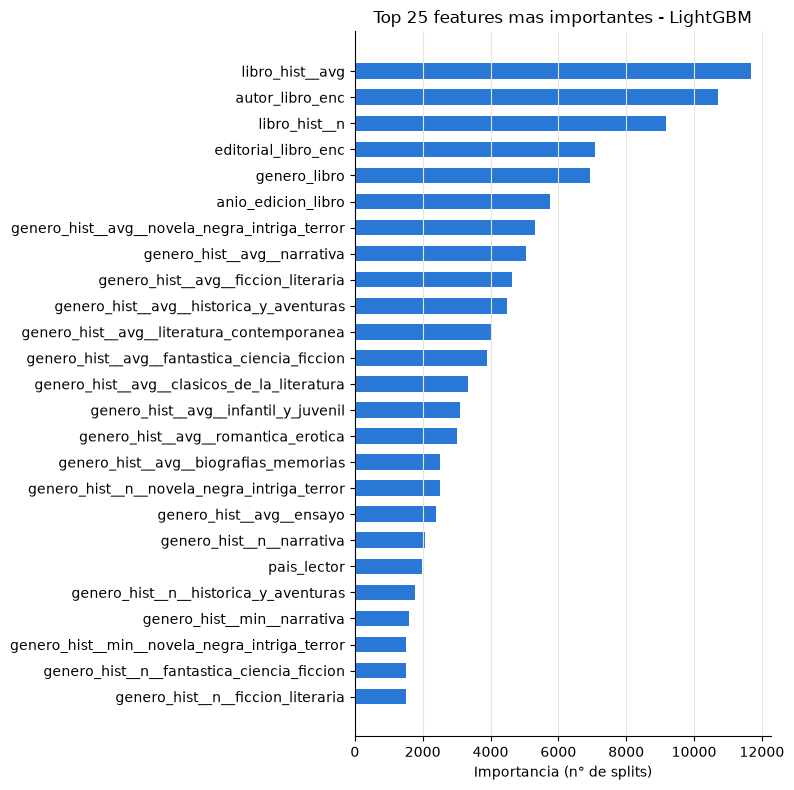

In [7]:
importancias = pd.Series(final_search_model.feature_importances_, index=FEATURE_COLS).sort_values().tail(25)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importancias.index, importancias.values, color="#2a78d6", height=0.6)
ax.set_xlabel("Importancia (n° de splits)")
ax.set_title("Top 25 features mas importantes - LightGBM")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e5e0", linewidth=0.8, zorder=0)
plt.tight_layout()
plt.show()

## 5. Reentrenamiento final con el 100% de los datos

Mismos hiperparámetros óptimos, pero el target encoding de autor/editorial se recalcula con el 100% de
los datos (ya no hay test que proteger) y `n_estimators` queda fijo en el `best_iteration` de la
sección anterior (sin *early stopping*, no hay held-out set).

In [8]:
encodings_full = {}
df_full_feat = df.copy()
for c in ENC_COLS:
    enc_map, media_global = ajustar_encoding(df_full_feat[c], df_full_feat[TARGET])
    encodings_full[c] = (enc_map, media_global)
    df_full_feat[f"{c}_enc"] = aplicar_encoding(df_full_feat[c], enc_map, media_global)

X_full = df_full_feat[FEATURE_COLS]
y_full = df_full_feat[TARGET].astype(float)

N_ESTIMATORS_FINAL = final_search_model.best_iteration_
final_model = lgb.LGBMRegressor(
    n_estimators=N_ESTIMATORS_FINAL, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1, **best_params
)
t0 = time.time()
final_model.fit(X_full, y_full, categorical_feature=CAT_COLS)
print(f"modelo final: {N_ESTIMATORS_FINAL} arboles, entrenado con {len(X_full):,} filas en {time.time() - t0:.0f}s")

modelo final: 1173 arboles, entrenado con 461,073 filas en 34s


Guardamos el modelo y todo lo necesario para reconstruir features de predicción (encodings de
autor/editorial, categorías vistas en entrenamiento, listas de columnas) en un solo archivo. Así, para
volver a generar recomendaciones con otro criterio de candidatos (o para cualquier otro cambio que solo
afecte a la sección de predicción) no hace falta repetir la búsqueda bayesiana ni el entrenamiento —
alcanza con cargar este artefacto en un notebook aparte.

In [9]:
joblib.dump(
    {
        "final_model": final_model,
        "encodings_full": encodings_full,
        "cat_categories": cat_categories,
        "FEATURE_COLS": FEATURE_COLS,
        "CAT_COLS": CAT_COLS,
        "ENC_COLS": ENC_COLS,
        "M_SUAVIZADO": M_SUAVIZADO,
    },
    ARTIFACTS_PATH,
)
print(f"artefactos guardados en {ARTIFACTS_PATH}")

artefactos guardados en datos/modelo_lightgbm_artifacts.joblib


## 6. Perfil de género actual por lector y catálogo de candidatos

Reconstruimos, desde `data.db`, el mismo pipeline de `dataset_features_genero.ipynb` (fuzzy matching de
género + changelog acumulado por lector×género vía SQL) para poder calcular el **perfil de género
actual** de cada lector: a diferencia del entrenamiento (que corta estrictamente antes de la fecha de
cada calificación, para no filtrar información), acá no hay ninguna fecha futura que proteger — usamos
directamente el estado acumulado con **todo** el historial del lector hasta su última calificación.

Por el mismo motivo, el catálogo de candidatos (más abajo) también necesita su propio historial de
libro **actual** — `libro_hist__n` / `libro_hist__avg` calculados sobre *todas* las calificaciones que
tiene cada libro hoy (no un corte por fecha), para que las columnas del dataset de predicción coincidan
exactamente con `FEATURE_COLS`.

In [10]:
def agrupar_por_similitud(items, threshold, scorer=fuzz.ratio):
    # une items en clusters (union-find) segun similitud; devuelve tambien los pares que dispararon cada union
    padre = {it: it for it in items}

    def find(x):
        while padre[x] != x:
            padre[x] = padre[padre[x]]
            x = padre[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            padre[ra] = rb

    pares = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            score = scorer(items[i], items[j])
            if score >= threshold:
                pares.append((items[i], items[j], score))
                union(items[i], items[j])

    clusters = {}
    for it in items:
        clusters.setdefault(find(it), []).append(it)
    return clusters, pares


def slugify(genero_norm: str) -> str:
    s = unicodedata.normalize("NFKD", genero_norm).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

In [11]:
conn = sqlite3.connect(DB_PATH)

q_conteo_genero = """
SELECT LOWER(TRIM(l.genero)) AS g, COUNT(*) AS n
FROM interacciones i JOIN libros l ON l.id_libro = i.id_libro
WHERE l.genero IS NOT NULL AND TRIM(l.genero) <> ''
GROUP BY g
"""
conteo_genero = pd.read_sql_query(q_conteo_genero, conn).set_index("g")["n"].to_dict()
clusters_genero, _ = agrupar_por_similitud(sorted(conteo_genero.keys()), 80)

genero_canon = {"desconocido": "desconocido"}
for miembros in clusters_genero.values():
    canonico = max(miembros, key=lambda m: conteo_genero.get(m, 0))
    for m in miembros:
        genero_canon[m] = canonico
print(f"genero_canon: {len(genero_canon)} generos originales -> {len(set(genero_canon.values()))} canonicos")

genero_canon: 55 generos originales -> 53 canonicos


In [12]:
conn.execute("CREATE TEMP TABLE genero_canon (genero_norm TEXT PRIMARY KEY, genero_canonico TEXT NOT NULL)")
conn.executemany("INSERT INTO genero_canon VALUES (?, ?)", list(genero_canon.items()))

query_changelog = """
WITH base AS (
    SELECT
        i.id_lector,
        COALESCE(gc.genero_canonico, 'desconocido') AS genero_norm,
        substr(i.fecha, 7, 4) || '-' || substr(i.fecha, 4, 2) || '-' || substr(i.fecha, 1, 2) AS fecha_iso,
        i.rating AS rating
    FROM interacciones i
    JOIN libros l    ON l.id_libro = i.id_libro
    JOIN lectores r  ON r.id_lector = i.id_lector
    LEFT JOIN genero_canon gc ON gc.genero_norm = LOWER(TRIM(l.genero))
    WHERE i.fecha GLOB '[0-9][0-9]-[0-9][0-9]-[0-9][0-9][0-9][0-9]'
),
por_dia AS (
    SELECT
        id_lector, genero_norm, fecha_iso,
        COUNT(*) AS n_dia, SUM(rating) AS suma_dia, MIN(rating) AS min_dia, MAX(rating) AS max_dia
    FROM base
    GROUP BY id_lector, genero_norm, fecha_iso
)
SELECT
    id_lector, genero_norm, fecha_iso,
    SUM(n_dia)    OVER w AS n_acum,
    SUM(suma_dia) OVER w AS suma_acum,
    MIN(min_dia)  OVER w AS min_acum,
    MAX(max_dia)  OVER w AS max_acum
FROM por_dia
WINDOW w AS (
    PARTITION BY id_lector, genero_norm
    ORDER BY fecha_iso
    RANGE BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
)
"""
t0 = time.time()
changelog = pd.read_sql_query(query_changelog, conn)
changelog["fecha_iso"] = pd.to_datetime(changelog["fecha_iso"])
print(f"changelog: {changelog.shape} en {time.time() - t0:.1f}s")

changelog: (246671, 7) en 1.6s


In [13]:
genero_slug = {g: slugify(g) for g in changelog["genero_norm"].unique()}
assert len(set(genero_slug.values())) == len(genero_slug)

wide_hist = changelog.pivot(
    index=["id_lector", "fecha_iso"], columns="genero_norm",
    values=["n_acum", "suma_acum", "min_acum", "max_acum"],
)
wide_hist.columns = [
    f"genero_hist__{metric.replace('_acum', '')}__{genero_slug[genero]}"
    for metric, genero in wide_hist.columns
]
wide_hist = wide_hist.reset_index().sort_values("fecha_iso")

n_cols_hist = [c for c in wide_hist.columns if c.startswith("genero_hist__n__")]
otras_cols = [c for c in wide_hist.columns if c.startswith("genero_hist__") and c not in n_cols_hist]
wide_hist[n_cols_hist] = wide_hist.groupby("id_lector")[n_cols_hist].ffill()
wide_hist[otras_cols] = wide_hist.groupby("id_lector")[otras_cols].ffill()

# perfil actual = ultimo estado de cada lector (todo su historial, sin cortar por fecha)
perfil_actual = wide_hist.sort_values("fecha_iso").groupby("id_lector").tail(1).drop(columns=["fecha_iso"])

suma_cols = [c for c in perfil_actual.columns if c.startswith("genero_hist__suma__")]
avg_nuevas = {}
for suma_c in suma_cols:
    tag = suma_c[len("genero_hist__suma__"):]
    n_c = f"genero_hist__n__{tag}"
    avg_nuevas[f"genero_hist__avg__{tag}"] = perfil_actual[suma_c] / perfil_actual[n_c].replace(0, np.nan)
perfil_actual = pd.concat([perfil_actual.drop(columns=suma_cols), pd.DataFrame(avg_nuevas, index=perfil_actual.index)], axis=1)
perfil_actual[n_cols_hist] = perfil_actual[n_cols_hist].fillna(0).astype("int32")

min_max_cols = [c for c in perfil_actual.columns if "__min__" in c or "__max__" in c]
perfil_actual[min_max_cols] = perfil_actual[min_max_cols].astype("float32")

print(f"perfil_actual: {perfil_actual.shape} (una fila por lector con historial)")
hist_feature_cols = [c for c in FEATURE_COLS if c.startswith("genero_hist__")]
faltan = set(hist_feature_cols) - set(perfil_actual.columns)
sobran = set(perfil_actual.columns) - set(hist_feature_cols) - {"id_lector"}
assert not faltan and not sobran, f"desalineacion de columnas de historial: faltan={faltan} sobran={sobran}"
print("OK: las columnas de historial coinciden exactamente con las de entrenamiento.")

perfil_actual: (10667, 213) (una fila por lector con historial)
OK: las columnas de historial coinciden exactamente con las de entrenamiento.


In [14]:
# candidatos: libros con >= MIN_RATINGS_RECOMENDABLE calificaciones validas (mismo criterio que
# recomendador_libros.ipynb) -- el 61% del catalogo no tiene genero/autor/editorial/anio, y los libros
# con muy pocas calificaciones dan un target encoding ruidoso que termina dominando el top-20
q_candidatos = """
SELECT
    l.id_libro,
    l.autor        AS autor_libro,
    l.genero        AS genero_libro_raw,
    l.editorial     AS editorial_libro,
    l.anio_edicion  AS anio_edicion_libro,
    conteo.n_ratings  AS n_ratings,
    conteo.avg_rating AS avg_rating
FROM libros l
JOIN (
    SELECT i.id_libro, COUNT(*) AS n_ratings, AVG(i.rating) AS avg_rating
    FROM interacciones i
    JOIN lectores r ON r.id_lector = i.id_lector
    WHERE i.fecha GLOB '[0-9][0-9]-[0-9][0-9]-[0-9][0-9][0-9][0-9]'
    GROUP BY i.id_libro
) conteo ON conteo.id_libro = l.id_libro
WHERE conteo.n_ratings >= ?
"""
candidatos = pd.read_sql_query(q_candidatos, conn, params=(MIN_RATINGS_RECOMENDABLE,))

candidatos["genero_libro"] = (
    candidatos["genero_libro_raw"].str.strip().str.lower().map(genero_canon).fillna("desconocido")
)
anio_num = pd.to_numeric(candidatos["anio_edicion_libro"], errors="coerce")
candidatos["anio_edicion_libro"] = anio_num.where(anio_num.between(1400, 2026))

# libro_hist__n / libro_hist__avg = estado actual del historial del libro (todo su historial hasta
# hoy, sin corte de fecha -- mismo criterio que el perfil de género actual más abajo: acá no hay fuga
# posible porque predecimos sobre libros que el lector no leyó)
candidatos["libro_hist__n"] = candidatos["n_ratings"].astype("int32")
candidatos["libro_hist__avg"] = candidatos["avg_rating"].astype("float32")
candidatos = candidatos.drop(columns=["genero_libro_raw", "n_ratings", "avg_rating"])

for c in ENC_COLS:
    enc_map, media_global = encodings_full[c]
    candidatos[f"{c}_enc"] = aplicar_encoding(candidatos[c], enc_map, media_global)
candidatos = candidatos.drop(columns=ENC_COLS)

candidatos["genero_libro"] = candidatos["genero_libro"].astype(pd.CategoricalDtype(categories=cat_categories["genero_libro"]))

libro_hist_feature_cols = [c for c in FEATURE_COLS if c.startswith("libro_hist__")]
faltan_libro_hist = set(libro_hist_feature_cols) - set(candidatos.columns)
assert not faltan_libro_hist, f"faltan columnas de historial de libro en candidatos: {faltan_libro_hist}"

print(f"libros candidatos (>= {MIN_RATINGS_RECOMENDABLE} calificaciones): {len(candidatos):,}")
print("nulos en columnas de candidatos:")
print(candidatos.isna().sum()[candidatos.isna().sum() > 0])

libros candidatos (>= 5 calificaciones): 12,115
nulos en columnas de candidatos:
anio_edicion_libro    8
dtype: int64


## 7. Lectores objetivo (`ejemplo.csv`) y libros ya leídos

`ejemplo.csv` trae una columna `id_lector` y una `id_libro` de ejemplo al azar (la ignoramos: solo nos
interesan los `id_lector` únicos). Para no recomendar algo que el lector ya calificó usamos **todas**
las interacciones (incluida la única fila con fecha corrupta) — para saber si ya lo leyó no hace falta
que la fecha sea válida, alcanza con que la interacción exista.

In [15]:
ejemplo = pd.read_csv(EJEMPLO_CSV)
lectores_objetivo = sorted(ejemplo["id_lector"].unique())
print(f"lectores objetivo: {len(lectores_objetivo)}")

lectores_tabla = pd.read_sql_query("SELECT id_lector, genero AS genero_lector, vive_en FROM lectores", conn)
lectores_tabla["genero_lector"] = lectores_tabla["genero_lector"].replace({"-": np.nan, "": np.nan})
lectores_tabla["pais_lector"] = (
    lectores_tabla["vive_en"].str.rsplit("-", n=1).str[-1].str.strip().str.lower()
    .replace({"": np.nan, "¿?": np.nan})
)
lectores_tabla = lectores_tabla.drop(columns=["vive_en"])
lectores_tabla["genero_lector"] = lectores_tabla["genero_lector"].astype(pd.CategoricalDtype(categories=cat_categories["genero_lector"]))
lectores_tabla["pais_lector"] = lectores_tabla["pais_lector"].astype(pd.CategoricalDtype(categories=cat_categories["pais_lector"]))

leidos = pd.read_sql_query("SELECT DISTINCT id_lector, id_libro FROM interacciones", conn)
conn.close()

perfil_lectores_obj = (
    pd.DataFrame({"id_lector": lectores_objetivo})
    .merge(lectores_tabla, on="id_lector", how="left")
    .merge(perfil_actual, on="id_lector", how="left")
)
n_cols_obj = [c for c in perfil_lectores_obj.columns if c.startswith("genero_hist__n__")]
perfil_lectores_obj[n_cols_obj] = perfil_lectores_obj[n_cols_obj].fillna(0)
perfil_lectores_obj = perfil_lectores_obj.copy()

sin_historial = perfil_lectores_obj["genero_hist__n__narrativa"].isna().sum()
print(f"lectores objetivo sin ningun historial previo (perfil vacio, cold-start): {sin_historial}")

lectores objetivo: 832


lectores objetivo sin ningun historial previo (perfil vacio, cold-start): 0


## 8. Predicción en batches y top-20 por lector

832 lectores × miles de candidatos son varios millones de pares — armar esa tabla completa de una sola
vez en memoria no entra cómodo, así que la procesamos en lotes de lectores: por cada lote, cruzamos con
el catálogo de candidatos, sacamos los ya leídos, predecimos, nos quedamos con el top 20 de cada lector
y descartamos el resto antes de pasar al siguiente lote.

In [16]:
BATCH_SIZE = 30
n_batches = int(np.ceil(len(perfil_lectores_obj) / BATCH_SIZE))
print(f"lectores: {len(perfil_lectores_obj)}  candidatos: {len(candidatos):,}  lotes: {n_batches}")

resultados = []
t_total = time.time()
for bi in range(n_batches):
    lote = perfil_lectores_obj.iloc[bi * BATCH_SIZE:(bi + 1) * BATCH_SIZE]

    cross = lote.merge(candidatos, how="cross")
    cross = cross.merge(leidos.assign(_leido=1), on=["id_lector", "id_libro"], how="left")
    cross = cross[cross["_leido"].isna()].drop(columns=["_leido"])

    cross["pred_rating"] = final_model.predict(cross[FEATURE_COLS])

    top20 = (
        cross.sort_values(["id_lector", "pred_rating"], ascending=[True, False])
        .groupby("id_lector", sort=False)
        .head(20)[["id_lector", "id_libro", "pred_rating"]]
    )
    resultados.append(top20)

    if (bi + 1) % 5 == 0 or bi == n_batches - 1:
        print(f"  lote {bi + 1}/{n_batches} ({time.time() - t_total:.0f}s acumulados)")

recomendaciones = pd.concat(resultados, ignore_index=True)
print(f"\ntotal: {recomendaciones.shape} en {time.time() - t_total:.0f}s")

lectores: 832  candidatos: 12,115  lotes: 28


  lote 5/28 (9s acumulados)


  lote 10/28 (19s acumulados)


  lote 15/28 (28s acumulados)


  lote 20/28 (38s acumulados)


  lote 25/28 (47s acumulados)


  lote 28/28 (52s acumulados)

total: (16640, 3) en 52s


## 9. Validaciones de sanidad

In [17]:
filas_por_lector = recomendaciones.groupby("id_lector").size()
print("lectores objetivo cubiertos:", filas_por_lector.index.isin(lectores_objetivo).all() and len(filas_por_lector) == len(lectores_objetivo))
print("distribucion de filas por lector:")
print(filas_por_lector.value_counts())

incompletos = filas_por_lector[filas_por_lector < 20]
if len(incompletos):
    print(f"\n{len(incompletos)} lectores con menos de 20 recomendaciones (menos de 20 candidatos sin leer disponibles):")
    print(incompletos)

dup = recomendaciones.duplicated(subset=["id_lector", "id_libro"]).sum()
print(f"\npares (lector, libro) duplicados: {dup}")

ya_leidos_set = set(map(tuple, leidos[["id_lector", "id_libro"]].itertuples(index=False, name=None)))
recomendados_set = set(map(tuple, recomendaciones[["id_lector", "id_libro"]].itertuples(index=False, name=None)))
interseccion = recomendados_set & ya_leidos_set
print(f"recomendaciones que en realidad ya estaban leidas (deberia ser 0): {len(interseccion)}")

assert dup == 0, "hay pares (lector, libro) duplicados"
assert len(interseccion) == 0, "se recomendo un libro ya leido"
print("\nOK: sin duplicados, sin libros ya leidos.")

lectores objetivo cubiertos: True
distribucion de filas por lector:
20    832
Name: count, dtype: int64

pares (lector, libro) duplicados: 0
recomendaciones que en realidad ya estaban leidas (deberia ser 0): 0

OK: sin duplicados, sin libros ya leidos.


## 10. CSV final (misma estructura que `ejemplo.csv`)

In [18]:
salida = (
    recomendaciones.sort_values(["id_lector", "pred_rating"], ascending=[True, False])
    [["id_lector", "id_libro"]]
    .reset_index(drop=True)
)

print("columnas:", salida.columns.tolist(), "== ejemplo.csv:", salida.columns.tolist() == ejemplo.columns.tolist())
print("filas:", len(salida), " (ejemplo.csv tiene", len(ejemplo), ")")
print("lectores unicos:", salida["id_lector"].nunique(), " (ejemplo.csv tiene", ejemplo["id_lector"].nunique(), ")")

salida.to_csv(OUTPUT_CSV, index=False)
print(f"\nguardado en {OUTPUT_CSV}")
salida.head(10)

columnas: ['id_lector', 'id_libro'] == ejemplo.csv: True
filas: 16640  (ejemplo.csv tiene 16640 )
lectores unicos: 832  (ejemplo.csv tiene 832 )

guardado en datos/recomendaciones_top20_lightgbm.csv


,id_lector,id_libro
0,05-03-1970,duelos-y-quebrantos
1,05-03-1970,estuche-trilogia-de-escipion-africanus-las-leg...
2,05-03-1970,el-tercer-encuentro
3,05-03-1970,mafalda-7
4,05-03-1970,maus
5,05-03-1970,mafalda-2
6,05-03-1970,blacksad-1-un-lugar-entre-las-sombras
7,05-03-1970,watchmen
8,05-03-1970,el-guerrero-a-la-sombra-del-cerezo
9,05-03-1970,mafalda-0


## 11. Resumen y ejemplo

In [19]:
conn = sqlite3.connect(DB_PATH)
libros_info = pd.read_sql_query("SELECT id_libro, titulo, autor, genero FROM libros", conn)
conn.close()

muestra = recomendaciones["id_lector"].drop_duplicates().sample(2, random_state=RANDOM_STATE).tolist()
for lid in muestra:
    top5 = recomendaciones[recomendaciones["id_lector"] == lid].sort_values("pred_rating", ascending=False).head(5)
    top5 = top5.merge(libros_info, on="id_libro", how="left")
    print(f"\n=== top 5 para {lid} ===")
    print(top5[["id_libro", "titulo", "autor", "genero", "pred_rating"]].to_string(index=False))


=== top 5 para omallorqui ===
                       id_libro                           titulo                            autor                        genero  pred_rating
                   madre-patria                     MADRE PATRIA            GULLO OMODEO, MARCELO                      Historia     8.372921
                        ibiza-1                            IBIZA                   MOLINA, XAVIER Novela negra, intriga, terror     8.320236
todo-mafalda-edicion-definitiva TODO MAFALDA. Edición definitiva LAVADO TEJÓN, JOAQUÍN S. (QUINO)        Cómics, Novela Gráfica     8.257634
          todo-mafalda-ampliado TODO MAFALDA. Edición definitiva LAVADO TEJÓN, JOAQUÍN S. (QUINO)        Cómics, Novela Gráfica     8.201826
               libelo-de-sangre                 LIBELO DE SANGRE                      AZA, SANDRA Novela negra, intriga, terror     8.197728

=== top 5 para xisqui ===
                             id_libro                                            titulo         

**Resumen**:

- `autor_libro` (20.684 valores) y `editorial_libro` (2.786) se reemplazaron por target encoding
  suavizado (leak-safe) en vez de categóricas nativas — con `num_leaves`/`min_child_samples` amplios,
  la búsqueda de splits categóricos sobre esa cardinalidad podía volverse extremadamente lenta.
- Optimización bayesiana con Optuna (TPE) sobre `learning_rate`, `num_leaves`, `min_child_samples`,
  `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, minimizando RMSE en el 20% de test.
- El mejor modelo se reentrenó dejándolo converger del todo (sección 4) y se comparó contra baselines
  simples (media global, promedio del libro, promedio del lector, todos calculados solo con train).
- El modelo de producción (sección 5) se reentrena con el 100% del dataset y los hiperparámetros
  óptimos, con `n_estimators` fijo en el `best_iteration` encontrado en la evaluación honesta, y el
  target encoding recalculado con el 100% de los datos.
- Para predecir, cada lector de `ejemplo.csv` recibe su **perfil de género completo** (todo su
  historial, sin corte de fecha) y se puntúan los libros candidatos (con >= 5 calificaciones válidas)
  que no leyó. El resultado final (`datos/recomendaciones_top20_lightgbm.csv`) tiene la misma estructura
  que `datos/ejemplo.csv`: 20 filas por lector, ordenadas por score predicho descendente.